# Seaborn Exercises

Time to practice your new seaborn skills! Try to recreate the plots below (don't worry about color schemes, just the plot itself.

## The Data

We will be working with a famous titanic data set for these exercises. Later on in the Machine Learning section of the course, we will revisit this data, and use it to predict survival rates of passengers. For now, we'll just focus on the visualization of the data with seaborn:

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline

In [2]:
sns.set_style('whitegrid')

In [3]:
titanic = sns.load_dataset('titanic')

In [4]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Exercises

**Recreate the plots below using the titanic dataframe. There are very few hints since most of the plots can be done with just one or two lines of code and a hint would basically give away the solution. Keep careful attention to the x and y labels for hints.**

**Note! In order to not lose the plot image, make sure you don't code in the cell that is directly above the plot, there is an extra cell above that one which won't overwrite that plot!**

Text(0.55, 0.95, 'pearsonr = 0.096; p = 0.01')

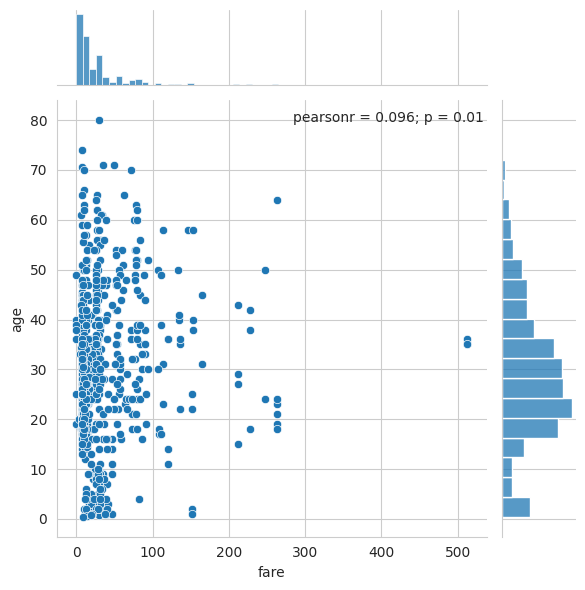

In [5]:
plot = sns.jointplot(x="fare", y="age", data=titanic, palette="coolwarm")

clean_df = titanic[["fare", "age"]].dropna()
r, p = stats.pearsonr(clean_df["fare"], clean_df["age"])

plot.ax_joint.annotate(
    f"pearsonr = {r:.3f}; p = {p:.2g}",
    xy=(.55, .95),
    xycoords="axes fraction"
)

(0.0, 500.0)

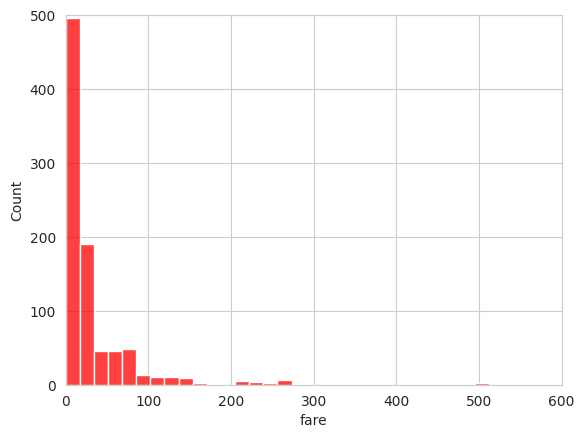

In [ ]:
fig, ax = plt.subplots()
sns.histplot(x="fare", data=titanic, ax=ax, bins=30, color="red")

ax.set_xlim((0, 600))
ax.set_ylim((0, 500))

<Axes: xlabel='class', ylabel='age'>

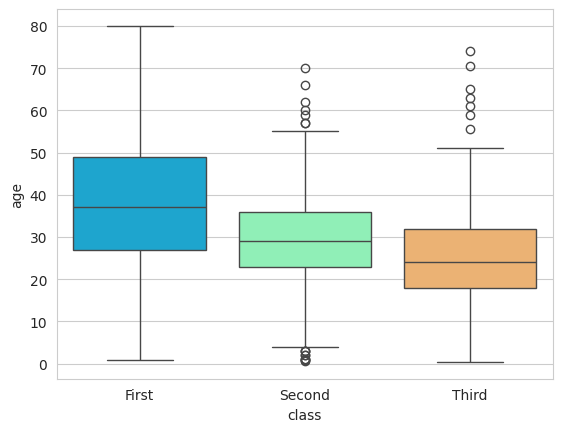

In [ ]:
# use hue= with the same value as x=, but add dodge=False
sns.boxplot(
    x="class", y="age", data=titanic, hue="class", dodge=False, palette="rainbow"
)

<Axes: xlabel='class', ylabel='age'>

/home/andrei/Work/personal/study/py.for.data.analysis/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 8.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


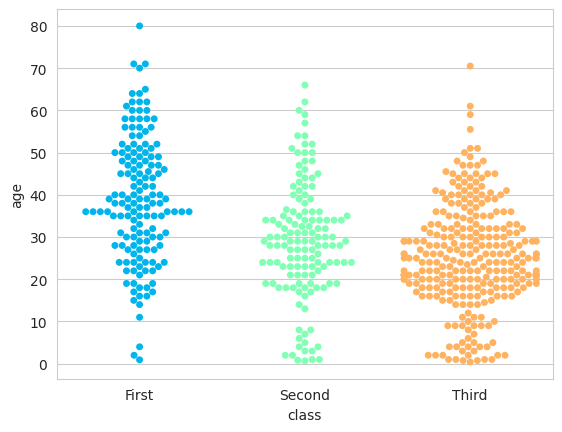

In [26]:
# for swarmplots, we might want to reduce the number of samples
sampled = (
    titanic.dropna(subset=["class", "age"])
    .groupby("class", group_keys=False)
    .sample(frac=.8, random_state=42)
)

sns.swarmplot(
    x="class", y="age", data=sampled, hue="class", dodge=False, palette="rainbow"
)

<Axes: xlabel='sex', ylabel='count'>

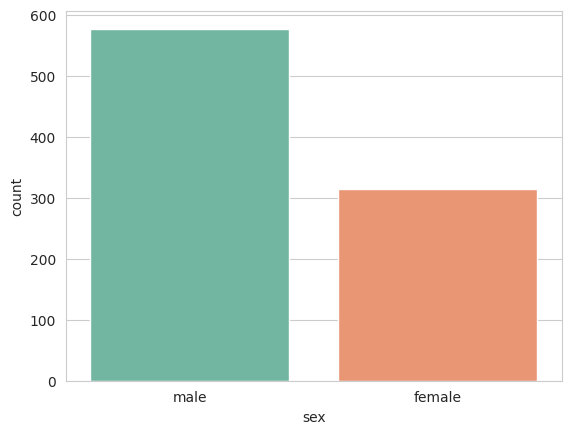

In [10]:

sns.countplot(x="sex", data=titanic, hue="sex", dodge=False, palette="Set2")

<Axes: >

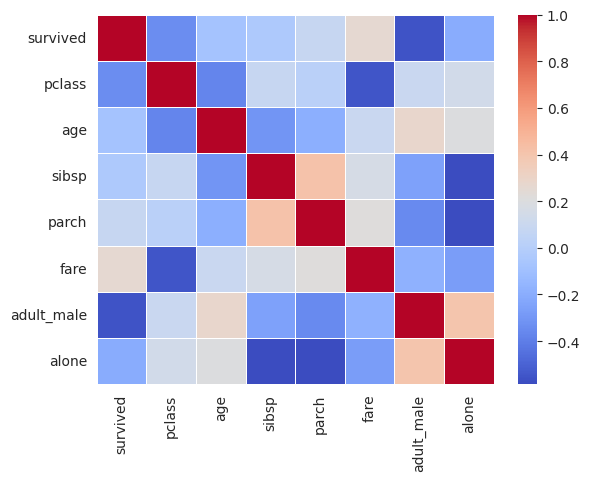

In [11]:
corr_data = titanic.corr(numeric_only=True)

sns.heatmap(corr_data, cmap="coolwarm", annot=False, fmt=".2f", linewidths=.5)

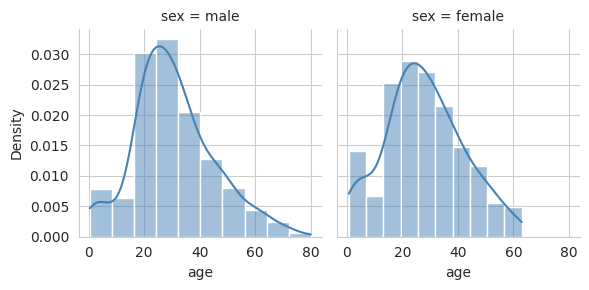

In [14]:
g = sns.FacetGrid(data=titanic.dropna(subset=["age"]), col="sex")
g.map_dataframe(sns.histplot, x="age", bins=10, stat="density", kde=True, color="steelblue")

# Great Job!

### That is it for now! We'll see a lot more of seaborn practice problems in the machine learning section!